In [95]:
# !pip install torch_geometric

In [159]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
from torch_geometric.nn import GCNConv, GATv2Conv, global_mean_pool
from torch_geometric.data import Data, Batch
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import networkx as nx
from tqdm import tqdm

class TemporalGNN(nn.Module):
    def __init__(self, in_channels=3, hidden_channels=64, out_channels=128, num_layers=3):
        super(TemporalGNN, self).__init__()
        
        # GNN layers
        self.convs = nn.ModuleList()
        self.convs.append(GATv2Conv(in_channels, hidden_channels))
        
        for _ in range(num_layers - 2):
            self.convs.append(GATv2Conv(hidden_channels, hidden_channels))
        
        self.convs.append(GATv2Conv(hidden_channels, hidden_channels))
        
        # Temporal attention layers
        self.temporal_attn = nn.MultiheadAttention(embed_dim=hidden_channels, 
                                                  num_heads=4, 
                                                  batch_first=True)
        
        # Final MLP for embedding generation
        self.mlp = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, out_channels)
        )
        
    def forward(self, data_list):
        """
        Process a list of graph snapshots representing a dance sequence
        
        Args:
            data_list: List of torch_geometric Data objects, each representing a frame
                       in the motion sequence
        
        Returns:
            embeddings: The final dance sequence embedding
        """
        batch_size = len(data_list)
        seq_len = len(data_list[0])
        
        # Process each graph snapshot with GNN
        frame_embeddings = []
        
        for batch_idx in range(batch_size):
            sequence_embeddings = []
            
            for frame_idx in range(seq_len):
                data = data_list[batch_idx][frame_idx]
                x, edge_index = data.x, data.edge_index
                
                # Apply GNN layers
                for conv in self.convs:
                    x = conv(x, edge_index)
                    x = F.relu(x)
                    x = F.dropout(x, p=0.2, training=self.training)
                
                # Global pooling to get graph-level representation
                batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
                pooled = global_mean_pool(x, batch)
                
                sequence_embeddings.append(pooled)
                
            # Stack frame embeddings for this sequence
            sequence_embeddings = torch.stack(sequence_embeddings, dim=0)  # [seq_len, hidden_dim]
            
            # Apply temporal attention
            attn_out, _ = self.temporal_attn(sequence_embeddings, 
                                            sequence_embeddings, 
                                            sequence_embeddings)
            
            # Get sequence representation by averaging over frames
            seq_repr = attn_out.mean(dim=0)  # [hidden_dim]
            
            # Final embedding
            embedding = self.mlp(seq_repr)  # [out_channels]
            frame_embeddings.append(embedding)
            
        # Stack all sequence embeddings
        embeddings = torch.stack(frame_embeddings, dim=0)  # [batch_size, out_channels]
        
        return embeddings


def motion_to_graph_sequence(motion_data, point_labels, skeleton_lines):
    """
    Convert motion capture data to a sequence of graph snapshots
    
    Args:
        motion_data: numpy array of shape (n_frames, n_joints, 3)
        point_labels: list of joint names
        skeleton_lines: list of tuples defining the skeleton connections
    
    Returns:
        graph_sequence: list of torch_geometric Data objects
    """
    n_frames, n_joints, _ = motion_data.shape
    graph_sequence = []
    
    # Create mapping from joint names to indices
    joint_to_idx = {joint: i for i, joint in enumerate(point_labels)}
    
    # Build edge index from skeleton lines
    edges = []
    for connection in skeleton_lines:
        # Each connection is ((joint1,), (joint2,))
        src_joint = connection[0][0]
        dst_joint = connection[1][0]
        
        if src_joint in joint_to_idx and dst_joint in joint_to_idx:
            src_idx = joint_to_idx[src_joint]
            dst_idx = joint_to_idx[dst_joint]
            edges.append([src_idx, dst_idx])
            edges.append([dst_idx, src_idx])  # Add bidirectional edges
    
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    
    # Create a graph for each frame
    for frame_idx in range(n_frames):
        # Node features are the 3D positions
        x = torch.tensor(motion_data[frame_idx], dtype=torch.float)
        
        # Create graph data object
        data = Data(x=x, edge_index=edge_index)
        graph_sequence.append(data)
    
    return graph_sequence


def prepare_batched_sequences(motion_data, point_labels, skeleton_lines, seq_length=30, stride=15):
    """
    Prepare batched sequences of motion data
    
    Args:
        motion_data: numpy array of shape (n_frames, n_joints, 3)
        point_labels: list of joint names
        skeleton_lines: list of tuples defining the skeleton connections
        seq_length: length of each sequence
        stride: stride between consecutive sequences
    
    Returns:
        batched_sequences: list of lists of torch_geometric Data objects
    """
    n_frames = motion_data.shape[0]
    batched_sequences = []
    
    # Create sequences with sliding window
    for start_idx in range(0, n_frames - seq_length + 1, stride):
        end_idx = start_idx + seq_length
        sequence_data = motion_data[start_idx:end_idx]
        
        # Convert to graph sequence
        graph_sequence = motion_to_graph_sequence(sequence_data, point_labels, skeleton_lines)
        batched_sequences.append(graph_sequence)
    
    return batched_sequences


def train_gnn(motion_data, point_labels, skeleton_lines, seq_length=30, stride=15, 
             batch_size=16, epochs=50, learning_rate=0.001):
    """
    Train the GNN model on motion data
    
    Args:
        motion_data: numpy array of shape (n_frames, n_joints, 3)
        point_labels: list of joint names
        skeleton_lines: list of tuples defining the skeleton connections
        seq_length: length of each sequence
        stride: stride between consecutive sequences
        batch_size: batch size for training
        epochs: number of training epochs
        learning_rate: learning rate for the optimizer
    
    Returns:
        model: trained model
        embeddings: generated embeddings for all sequences
    """
    # Prepare data
    sequences = prepare_batched_sequences(motion_data, point_labels, skeleton_lines, 
                                         seq_length, stride)
    
    # Create model
    model = TemporalGNN()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train model
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        
        # Process in batches
        for i in tqdm(range(0, len(sequences), batch_size)):
            batch_sequences = sequences[i:i + batch_size]
            
            # Forward pass
            embeddings = model(batch_sequences)
            
            # Compute triplet loss
            # We'll use random triplets for simplicity
            # In real applications, you might want to use more sophisticated triplet mining
            anchor = embeddings
            
            # Create positive examples by adding small noise
            positive = anchor + torch.randn_like(anchor) * 0.05
            
            # Create negative examples by shuffling the batch
            negative_idx = torch.randperm(len(batch_sequences))[:len(batch_sequences)]
            negative = embeddings[negative_idx]
            
            # Compute triplet loss
            distance_pos = F.pairwise_distance(anchor, positive)
            distance_neg = F.pairwise_distance(anchor, negative)
            
            # Margin triplet loss
            margin = 1.0
            loss = F.relu(distance_pos - distance_neg + margin).mean()
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")
    
    # Generate embeddings for all sequences
    model.eval()
    all_embeddings = []
    
    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch_sequences = sequences[i:i + batch_size]
            embeddings = model(batch_sequences)
            all_embeddings.append(embeddings)
    
    all_embeddings = torch.cat(all_embeddings, dim=0).numpy()
    
    return model, all_embeddings.squeeze(1)  # Removes extra dimension


import numpy as np
from sklearn.cluster import KMeans

def cluster_embeddings(embeddings, n_clusters=10):
    """
    Cluster the embeddings using K-means
    
    Args:
        embeddings: numpy array of embeddings
        n_clusters: number of clusters
    
    Returns:
        labels: cluster labels for each embedding
        centroids: cluster centroids
    """
    # # Reshape embeddings to 2D
    # if len(embeddings.shape) > 2:
    #     embeddings = embeddings.reshape(embeddings.shape[0], -1)

    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    labels = kmeans.fit_predict(embeddings)
    centroids = kmeans.cluster_centers_
    
    return labels, centroids


def visualize_embeddings(embeddings, labels):
    """
    Visualize the embeddings using t-SNE
    
    Args:
        embeddings: numpy array of embeddings
        labels: cluster labels for each embedding
    """
    # Apply t-SNE for dimensionality reduction
    tsne = TSNE(n_components=2, random_state=0)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='viridis', alpha=0.7)
    plt.colorbar(scatter)
    plt.title('t-SNE Visualization of Dance Sequence Embeddings')
    plt.tight_layout()
    plt.savefig('dance_embeddings.png')
    plt.close()


def example_usage():
    """Example usage of the entire pipeline"""
    # Assuming you have loaded your motion data as a numpy array
    # motion_data shape: (n_frames, n_joints, 3)
    
    # For demonstration, let's create random data
    n_frames = 1000
    n_joints = 55  # Number of joints in your data
    motion_data = np.random.randn(n_frames, n_joints, 3)
    
    # Define point labels and skeleton lines
    # Using the ones provided in your question
    
    # Train the model and get embeddings
    model, embeddings = train_gnn(motion_data, point_labels, skeleton_lines)
    
    # Cluster the embeddings
    n_clusters = 15  # Adjust based on your needs
    labels, centroids = cluster_embeddings(embeddings, n_clusters)
    
    # Visualize the embeddings
    visualize_embeddings(embeddings, labels)
    
    # Save the model and embeddings
    torch.save(model.state_dict(), 'dance_gnn_model.pt')
    np.save('dance_embeddings.npy', embeddings)
    np.save('dance_cluster_labels.npy', labels)
    
    print("Done! Model trained, embeddings generated and clustered.")
    
    return model, embeddings, labels


In [273]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
# from dance_gnn import TemporalGNN, motion_to_graph_sequence, prepare_batched_sequences, train_gnn, cluster_embeddings

# Load your motion capture data
# Assuming data is in the format (timestamps, 55 joints, 3 dimensions)
# Replace this with your actual data loading code
def load_motion_capture_data(file_path):
    # Load your motion capture data
    # This is just a placeholder - implement based on your data format
    data = np.load(file_path)[:,:1600,:]
    return data

# Example joint labels and skeleton connections
# These are provided in your question
point_labels = ['ARIEL', 'C7', 'CLAV', 'LANK', 'LBHD', 'LBSH', 'LBWT', 'LELB', 'LFHD', 'LFRM', 
                'LFSH', 'LFWT', 'LHEL', 'LIEL', 'LIHAND', 'LIWR', 'LKNE', 'LKNI', 'LMT1', 'LMT5', 
                'LOHAND', 'LOWR', 'LSHN', 'LTHI', 'LTOE', 'LUPA', 'MBWT', 'MFWT', 'RANK', 'RBHD', 
                'RBSH', 'RBWT', 'RELB', 'RFHD', 'RFRM', 'RFSH', 'RFWT', 'RHEL', 'RIEL', 'RIHAND', 
                'RIWR', 'RKNE', 'RKNI', 'RMT1', 'RMT5', 'ROHAND', 'ROWR', 'RSHN', 'RTHI', 'RTOE', 
                'RUPA', 'STRN', 'T10']
                
skeleton_lines = [
    (('LHEL',), ('LTOE',)), (('RHEL',), ('RTOE',)), (('LMT1',), ('LMT5',)), (('RMT1',), ('RMT5',)),
    (('LHEL',), ('LMT1',)), (('LHEL',), ('LMT5',)), (('RHEL',), ('RMT1',)), (('RHEL',), ('RMT5',)),
    (('LTOE',), ('LMT1',)), (('LTOE',), ('LMT5',)), (('RTOE',), ('RMT1',)), (('RTOE',), ('RMT5',)),
    (('LKNE',), ('LHEL',)), (('RKNE',), ('RHEL',)), (('LFWT',), ('RBWT',)), (('RFWT',), ('LBWT',)),
    (('LFWT',), ('RFWT',)), (('LBWT',), ('RBWT',)), (('LFWT',), ('LBWT',)), (('RFWT',), ('RBWT',)),
    (('LFWT',), ('LTHI',)), (('RFWT',), ('RTHI',)), (('LBWT',), ('LTHI',)), (('RBWT',), ('RTHI',)),
    (('LKNE',), ('LTHI',)), (('RKNE',), ('RTHI',)), 
    (('CLAV',), ('RFSH',)),
    (('STRN',), ('LFSH',)), (('STRN',), ('RFSH',)), (('T10',), ('LFSH',)), (('T10',), ('RFSH',)),
    (('C7',), ('LBSH',)), (('C7',), ('RBSH',)), (('LFSH',), ('LBSH',)), (('RFSH',), ('RBSH',)),
    (('LFSH',), ('RBSH',)), (('RFSH',), ('LBSH',)), (('LFSH',), ('LUPA',)), (('RFSH',), ('RUPA',)),
    (('LBSH',), ('LUPA',)), (('RBSH',), ('RUPA',)), (('LIWR',), ('LIHAND',)), (('RIWR',), ('RIHAND',)),
    (('LOWR',), ('LOHAND',)), (('ROWR',), ('ROHAND',)), (('LIWR',), ('LOWR',)), (('RIWR',), ('ROWR',)),
    (('LIHAND',), ('LOHAND',)), (('RIHAND',), ('ROHAND',)), (('LFHD',), ('LBHD',)), (('LBHD',), ('RBHD',)),
    (('RBHD',), ('RFHD',)), (('RFHD',), ('LFHD',)), (('LFHD',), ('ARIEL',)), (('LBHD',), ('ARIEL',)),
    (('RBHD',), ('ARIEL',)), 
    (('RFHD',), ('ARIEL',)),
    (('RFWT',), ('MFWT',)),(('LFWT',), ('MFWT',)),(('LFSH',), ('RFSH',))
]

# 1. Load the motion capture data
file_path = "../data/mariel_betternot_and_retrograde.npy"  # Replace with your data file
motion_data = load_motion_capture_data(file_path)
motion_data=motion_data.transpose(1,0,2)
print(f"Loaded motion data with shape: {motion_data.shape}")

# 2. Train the GNN model and generate embeddings
# You can adjust hyperparameters based on your needs
model, embeddings = train_gnn(
    motion_data=motion_data,
    point_labels=point_labels,
    skeleton_lines=skeleton_lines,
    seq_length=40,         # Length of each dance stequence
    stride=40,             # Overlap between sequences
    batch_size=64,         # Training batch size
    epochs=2,             # Number of training epochs
    learning_rate=0.001    # Learning rate
)

print(f"Generated {embeddings.shape[0]} embeddings with dimension {embeddings.shape[1]}")

# 3. Cluster the embeddings
# n_clusters = 15 # Adjust based on your data and needs
# labels, centroids = cluster_embeddings(embeddings, n_clusters)

# print(f"Clustered embeddings into {n_clusters} clusters")

# 4. Visualize the embeddings and clusters
# Reduce dimensionality for visualization
# tsne = TSNE(n_components=2, random_state=0)
# embeddings_2d = tsne.fit_transform(embeddings)

# # Plot
# plt.figure(figsize=(12, 10))
# scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='viridis', alpha=0.7)
# plt.colorbar(scatter, label='Cluster')
# plt.title('t-SNE Visualization of Dance Sequence Embeddings')
# plt.xlabel('t-SNE Dimension 1')
# plt.ylabel('t-SNE Dimension 2')
# plt.tight_layout()
# plt.savefig('dance_embeddings_clusters.png')
# plt.show()

# # 5. Save the model, embeddings, and cluster labels
torch.save(model.state_dict(), 'dance_gnn_model.pt')
# np.save('dance_embeddings.npy', embeddings)
# np.save('dance_cluster_labels.npy', labels)

# # 6. Select representative samples from each cluster for manual labeling
# # This helps you label only ~1% of the data
# sample_indices = []
# samples_per_cluster = max(1, int(0.01 * len(embeddings) / n_clusters))

# for cluster_id in range(n_clusters):
#     # Find indices of samples in this cluster
#     cluster_samples = np.where(labels == cluster_id)[0]
    
#     # Find samples closest to the centroid
#     distances = np.linalg.norm(embeddings[cluster_samples] - centroids[cluster_id], axis=1)
#     sorted_indices = np.argsort(distances)
    
#     # Select the top samples closest to centroid
#     selected = cluster_samples[sorted_indices[:samples_per_cluster]]
#     sample_indices.extend(selected)

# print(f"Selected {len(sample_indices)} samples for manual labeling")

# # 7. Save the indices of samples to label
# np.save('samples_to_label.npy', np.array(sample_indices))

# print("Done! You can now manually label the selected samples.")
# print("After labeling, you can use these labels to propagate to similar sequences within each cluster.")

Loaded motion data with shape: (1600, 55, 3)


100%|████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:05<00:00,  5.07s/it]


Epoch 1/2, Loss: 1.4359


100%|████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.63s/it]


Epoch 2/2, Loss: 1.3856
Generated 40 embeddings with dimension 128


In [274]:
emb = embeddings

In [277]:
emb.shape

(40, 128)

In [259]:
embeddings.shape

(99, 128)

In [261]:
print(np.isnan(embeddings).sum(), np.isinf(embeddings).sum())

0 0


In [263]:
embeddings = embeddings.astype(np.float32)

In [281]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2) 
embeddings_2d = pca.fit_transform(emb)

In [267]:
print(embeddings is None)  # Should print False

False


In [269]:
embeddings_2d.shape

(99, 2)

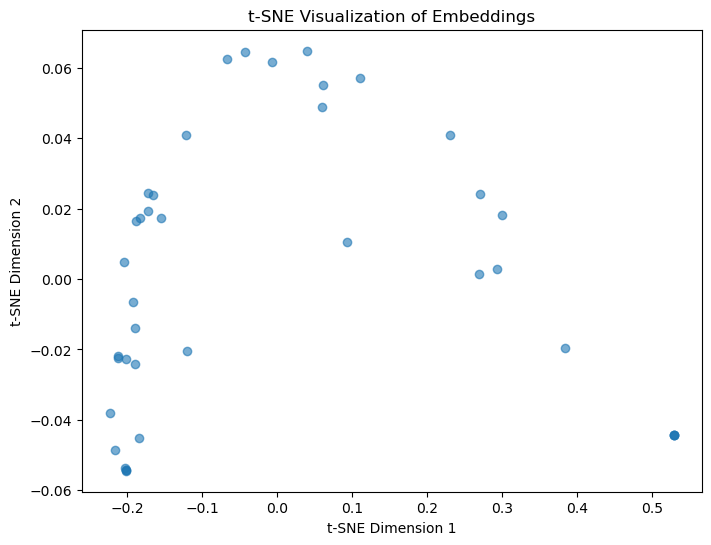

In [283]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6)
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.title("PCA Visualization of Embeddings")
plt.show()

In [307]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Assume we have 40 embeddings of shape (40, 128)
# embeddings = np.random.rand(40, 128)  # Replace this with actual embeddings

# Manually label 5 sequences (indices and their labels)
labeled_indices = [0, 5, 10, 15, 20]  # Example indices of labeled sequences
labels = [1, 0, 1, 0, 1]  # Corresponding labels

# Separate labeled and unlabeled data
X_labeled = embeddings[labeled_indices]
y_labeled = np.array(labels)

X_unlabeled = np.delete(embeddings, labeled_indices, axis=0)

# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')  # Use 3 nearest neighbors
knn.fit(X_labeled, y_labeled)

# Predict labels for the remaining 35 sequences
predicted_labels = knn.predict(X_unlabeled)

# Combine labeled and predicted labels
# final_labels = np.full(40, -1)  # Initialize all labels as -1 (unknown)
# final_labels[labeled_indices] = y_labeled  # Assign known labels
# final_labels[np.delete(np.arange(40), labeled_indices)] = predicted_labels  # Assign predicted labels

# print(final_labels)  # Final labels for all 40 sequences

AttributeError: 'NoneType' object has no attribute 'split'

In [303]:
predicted_labels

array([0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0])

In [289]:
X_labeled.shape

(5, 128)

In [291]:
X.shape

(35, 128)